# <center> Предсказание победителя в Dota 2
<center> <img src="https://248006.selcdn.ru/main/iblock/d52/d523440eddffa606bcf4e78a5011a822/2ef90fdbc3e9306a45851dca974be243.jpg" width="700" height="700">

[Почитать подбробнее](https://meduza.io/feature/2021/10/19/rossiyskaya-komanda-vyigrala-chempionat-mira-po-dota-2-i-poluchila-18-millionov-dollarov-postoyte-otkuda-takie-dengi-neuzheli-igrat-v-dotu-tak-slozhno)

#### [Оригинальная статья](https://arxiv.org/pdf/2106.01782.pdf)
    
### Начало

Посмотрим на готовые признаки и сделаем первую посылку.

1. [Описание данных](#Описание-данных)
2. [Описание признаков](#Описание-признаков)
3. [Наша первая модель](#Наша-первая-модель)
4. [Посылка](#Посылка)

### Первые шаги на пути в датасайенс

5. [Кросс-валидация](#Кросс-валидация)
6. [Что есть в json файлах?](#Что-есть-в-json-файлах?)
7. [Feature engineering](#Feature-engineering)

### Импорты

In [39]:
import os
import json
import pandas as pd
import datetime
import warnings
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, ShuffleSplit, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import GridSearchCV

%matplotlib inline

In [40]:
SEED = 10801
sns.set_style(style="whitegrid")
plt.rcParams["figure.figsize"] = 12, 8
warnings.filterwarnings("ignore")

## <left>Описание данных

Файлы:

- `sample_submission.csv`: пример файла-посылки
- `train_raw_data.jsonl`, `test_raw_data.jsonl`: "сырые" данные
- `train_data.csv`, `test_data.csv`: признаки, созданные авторами
- `train_targets.csv`: результаты тренировочных игр

## <left>Описание признаков
    
Набор простых признаков, описывающих игроков и команды в целом

In [41]:
PATH_TO_DATA = "/kaggle/input/copy-of-23-24-ml/"

df_train_features = pd.read_csv(os.path.join(PATH_TO_DATA,
                                             "train_data.csv"),
                                    index_col="match_id_hash")
df_train_targets = pd.read_csv(os.path.join(PATH_TO_DATA,
                                            "train_targets.csv"),
                                   index_col="match_id_hash")

In [42]:
df_train_features.shape

(31698, 245)

In [43]:
df_train_features.head()

,game_time,game_mode,lobby_type,objectives_len,chat_len,r1_hero_id,r1_kills,r1_deaths,r1_assists,r1_denies,...,d5_stuns,d5_creeps_stacked,d5_camps_stacked,d5_rune_pickups,d5_firstblood_claimed,d5_teamfight_participation,d5_towers_killed,d5_roshans_killed,d5_obs_placed,d5_sen_placed
match_id_hash,,,,,,,,,,,,,,,,,,,,,
b9c57c450ce74a2af79c9ce96fac144d,658,4,0,3,10,15,7,2,0,7,...,0.000000,0,0,0,0,0.00,0,0,0,0
6db558535151ea18ca70a6892197db41,21,23,0,0,0,101,0,0,0,0,...,0.000000,0,0,0,0,0.00,0,0,0,0
19c39fe2af2b547e48708ca005c6ae74,160,22,7,0,0,57,0,0,0,1,...,0.000000,0,0,0,0,0.00,0,0,0,0
c96d629dc0c39f0c616d1949938a6ba6,1016,22,0,1,0,119,0,3,3,5,...,8.264696,0,0,3,0,0.25,0,0,3,0
156c88bff4e9c4668b0f53df3d870f1b,582,22,7,2,2,12,3,1,2,9,...,15.762911,3,1,0,1,0.50,0,0,3,0


Имеем ~32 тысячи наблюдений, каждое из которых характеризуется уникальным `match_id_hash` (захэшированное id матча), и 245 признаков. `game_time` показывает момент времени, в который получены эти данные. То есть по сути это не длительность самого матча, а например, его середина, таким образом, в итоге мы сможем получить модель, которая будет предсказывать вероятность победы каждой из команд в течение матча (хорошо подходит для букмекеров).

Нас интересует поле `radiant_win` (так называется одна из команд, вторая - dire). Остальные колоки здесь по сути получены из "будущего" и есть только для тренировочных данных, поэтому на них можно просто посмотреть).

In [44]:
df_train_targets.head()

,game_time,radiant_win,duration,time_remaining,next_roshan_team
match_id_hash,,,,,
b9c57c450ce74a2af79c9ce96fac144d,658,True,1154,496,NaN
6db558535151ea18ca70a6892197db41,21,True,1503,1482,Radiant
19c39fe2af2b547e48708ca005c6ae74,160,False,2063,1903,NaN
c96d629dc0c39f0c616d1949938a6ba6,1016,True,2147,1131,Radiant
156c88bff4e9c4668b0f53df3d870f1b,582,False,1927,1345,Dire


## <left>Наша первая модель

In [45]:
X = df_train_features.values
y = df_train_targets["radiant_win"].values.astype("int8")

In [46]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y,
                                                      test_size=0.3,
                                                      random_state=SEED)

#### Обучим случайный лес

In [47]:
%%time
rf_model = RandomForestClassifier(n_estimators=300, max_depth=7, n_jobs=-1, random_state=SEED)
rf_model.fit(X_train, y_train)

CPU times: user 38.3 s, sys: 124 ms, total: 38.4 s
Wall time: 10 s


RandomForestClassifier(max_depth=7, n_estimators=300, n_jobs=-1,
                       random_state=10801)

#### Сделаем предсказания и оценим качество на отложенной части данных

In [48]:
y_pred = rf_model.predict_proba(X_valid)[:, 1]

In [49]:
valid_score = roc_auc_score(y_valid, y_pred)
print("ROC-AUC score на отложенной части:", valid_score)

ROC-AUC score на отложенной части: 0.7754387258058622


Посмотрим на accuracy:

In [50]:
valid_accuracy = accuracy_score(y_valid, y_pred > 0.5)
print("Accuracy score (p > 0.5) на отложенной части:", valid_accuracy)

Accuracy score (p > 0.5) на отложенной части: 0.6885383806519453


## <left>Посылка

In [13]:
df_test_features = pd.read_csv(os.path.join(PATH_TO_DATA, "test_data.csv"),
                                   index_col="match_id_hash")

X_test = df_test_features.values
y_test_pred = rf_model.predict_proba(X_test)[:, 1]

df_submission = pd.DataFrame({"radiant_win_prob": y_test_pred},
                                 index=df_test_features.index)

In [ ]:
submission_filename = "submission_{}.csv".format(
    datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S"))
df_submission.to_csv(submission_filename)
print("Файл посылки сохранен, как: {}".format(submission_filename))

## <left>Кросс-валидация

Во многих случаях кросс-валидация оказывается лучше простого разбиения на test и train. Воспользуемся `ShuffleSplit` чтобы создать 5 70%/30% наборов данных.

In [51]:
cv = ShuffleSplit(n_splits=5, test_size=0.3, random_state=SEED)

In [52]:
%%time
rf_model = RandomForestClassifier(n_estimators=300, max_depth=7, n_jobs=-1, random_state=SEED)
cv_scores_rf = cross_val_score(rf_model, X, y, cv=cv, scoring="roc_auc")

CPU times: user 3min 15s, sys: 743 ms, total: 3min 16s
Wall time: 52.9 s


In [53]:
cv_scores_rf

array([0.77543873, 0.77343884, 0.76649967, 0.7722681 , 0.77246001])

In [54]:
print(f"Среднее значение ROC-AUC на кросс-валидации: {cv_scores_rf.mean()}")

Среднее значение ROC-AUC на кросс-валидации: 0.7720210676055513


Получилось, что без кросс-валидации ROC-AUC ~ 0.775. 
На кросс-валидации ~ 0.772 (т.е. чутка меньше). На каггле: 0.78639.

## <left>Что есть в json файлах?

Описание сырых данных можно найти в `train_matches.jsonl` и `test_matches.jsonl`. Каждый файл содержит одну запись для каждого матча в [JSON](https://en.wikipedia.org/wiki/JSON) формате. Его легко превратить в питоновский объект при помощи метода `json.loads`.

In [55]:
with open(os.path.join(PATH_TO_DATA, "train_raw_data.jsonl")) as fin:
    # прочтем 419 строку
    for i in range(419):
        line = fin.readline()

    # переведем JSON в питоновский словарь
    match = json.loads(line)

In [19]:
match

{'game_time': 2049,
 'match_id_hash': '75112757bde649d5cff1c7cd4f1275c6',
 'teamfights': [{'start': 306.755,
   'end': 338.551,
   'last_death': 323.454,
   'deaths': 3,
   'players': [{'deaths_pos': {},
     'ability_uses': {'lich_frost_nova': 2, 'lich_dark_ritual': 1},
     'item_uses': {},
     'killed': {'npc_dota_hero_faceless_void': 114},
     'deaths': 0,
     'buybacks': 0,
     'damage': 383,
     'healing': 0,
     'gold_delta': 336,
     'xp_delta': 440},
    {'deaths_pos': {},
     'ability_uses': {'pudge_meat_hook': 1, 'pudge_rot': 1},
     'item_uses': {'smoke_of_deceit': 1, 'tpscroll': 1},
     'killed': {},
     'deaths': 0,
     'buybacks': 0,
     'damage': 458,
     'healing': 0,
     'gold_delta': -10,
     'xp_delta': 76},
    {'deaths_pos': {},
     'ability_uses': {},
     'item_uses': {},
     'killed': {},
     'deaths': 0,
     'buybacks': 0,
     'damage': 0,
     'healing': 0,
     'gold_delta': 174,
     'xp_delta': 249},
    {'deaths_pos': {},
     'abilit

In [56]:
player = match["players"][9]
player["kills"], player["deaths"], player["assists"]

(0, 5, 5)

In [57]:
(player["kills"] + player["deaths"])/player["assists"]

1.0

In [ ]:
player

KDA - может быть неплохим признаком, этот показатель считается как:
    
<center>$KDA = \frac{K + A}{D}$

Информация о количестве использованных способностей:

In [58]:
player["ability_uses"]#они ж все разные для разных персонажей

{'treant_living_armor': 52, 'treant_leech_seed': 5, 'treant_overgrowth': 5}

In [59]:
player["hero_id"]#герои кодируются цифрами, но по смыслу это категория

83

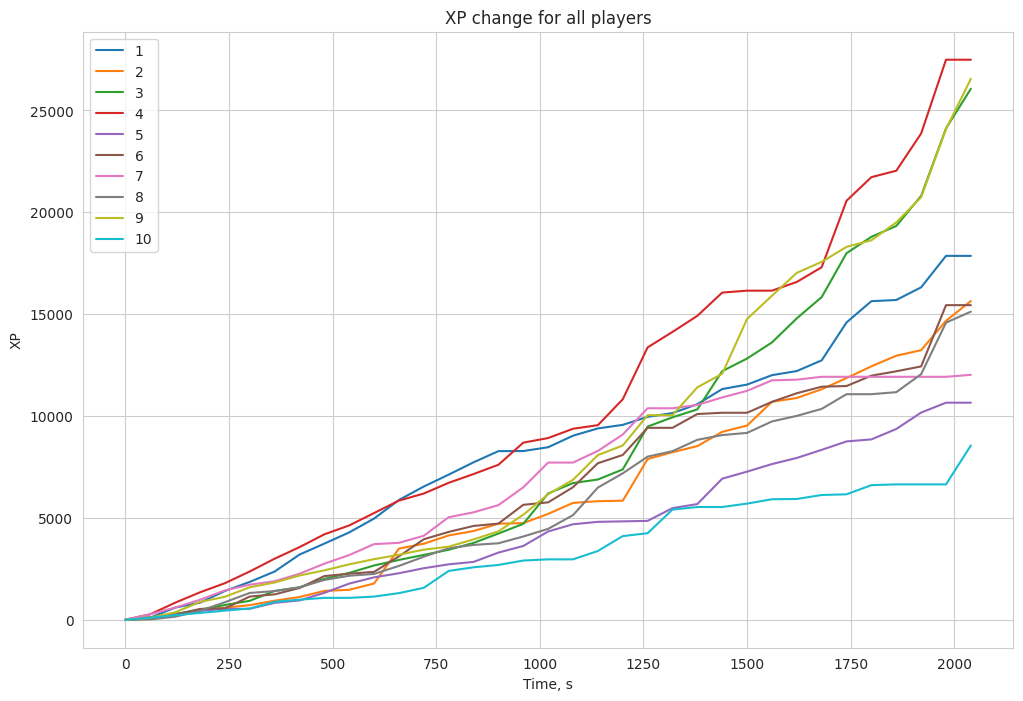

In [60]:
for i, player in enumerate(match["players"]):
    plt.plot(player["times"], player["xp_t"], label=str(i+1))

plt.legend()
plt.xlabel("Time, s")
plt.ylabel("XP")
plt.title("XP change for all players");

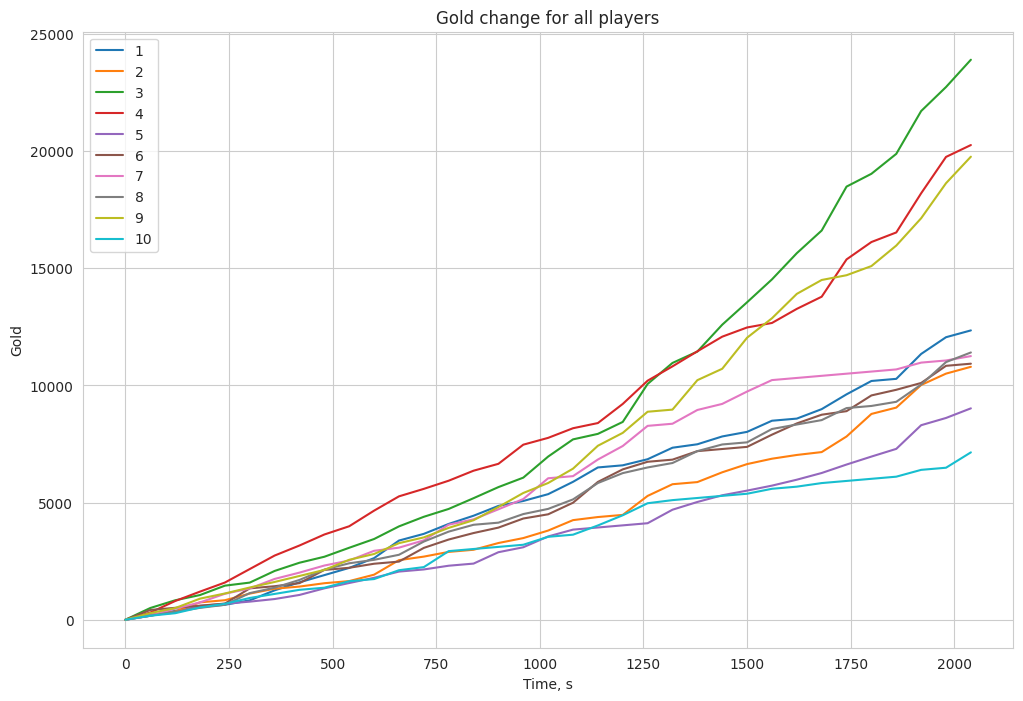

In [61]:
#ради интереса ещё на голду глянем
for i, player in enumerate(match["players"]):
    plt.plot(player["times"], player["gold_t"], label=str(i+1))

plt.legend()
plt.xlabel("Time, s")
plt.ylabel("Gold")
plt.title("Gold change for all players");
#ну кстати по голже 3ий вытянул, а по хп красный, но они все r

#### Сделаем чтение файла с сырыми данными и добавление новых признаков удобным

В этот раз для чтение `json` файлов лучше использовать библиотеку `ujson`, иначе все будет слишком долго :(

In [62]:
try:
    import ujson as json
except ModuleNotFoundError:
    import json
    print ("Подумайте об установке ujson, чтобы работать с JSON объектами быстрее")

try:
    from tqdm.notebook import tqdm
except ModuleNotFoundError:
    tqdm_notebook = lambda x: x
    print ("Подумайте об установке tqdm, чтобы следить за прогрессом")


def read_matches(matches_file, total_matches=31698, n_matches_to_read=None):
    """
    Аргумент
    -------
    matches_file: JSON файл с сырыми данными

    Результат
    ---------
    Возвращает записи о каждом матче
    """

    if n_matches_to_read is None:
        n_matches_to_read = total_matches

    c = 0
    with open(matches_file) as fin:
        for line in tqdm(fin, total=total_matches):
            if c >= n_matches_to_read:
                break
            else:
                c += 1
                yield json.loads(line)

#### Чтение данных в цикле

Чтение всех данных занимает 1-2 минуты, поэтому для начала можно попробовать следующее:

1. Читать 10-50 игр
2. Написать код для работы с этими JSON объектами
3. Убедиться, что все работает
4. Запустить код на всем датасете
5. Сохранить результат в `pickle` файл, чтобы в следующий раз не переделывать все заново

## <left>Feature engineering

Напишем функцию, которая поможет нам легче добавлять новые признаки.

In [63]:
def add_new_features(df_features, matches_file):
    """
    Аргументы
    -------
    df_features: таблица с данными
    matches_file: JSON файл с сырыми данными

    Результат
    ---------
    Добавляет новые признаки в таблицу
    """

    for match in read_matches(matches_file):
        match_id_hash = match['match_id_hash']
        
        
        #--------вторая версия модели--------

        # Посчитаем количество разрушенных вышек обеими командами
        radiant_tower_kills = 0
        dire_tower_kills = 0
        for objective in match["objectives"]:
            if objective["type"] == "CHAT_MESSAGE_TOWER_KILL":
                if objective["team"] == 2:
                    radiant_tower_kills += 1
                if objective["team"] == 3:
                    dire_tower_kills += 1

        df_features.loc[match_id_hash, "radiant_tower_kills"] = radiant_tower_kills
        df_features.loc[match_id_hash, "dire_tower_kills"] = dire_tower_kills
        df_features.loc[match_id_hash, "diff_tower_kills"] = radiant_tower_kills - dire_tower_kills
        #только с этими признаками на кросс-валидации ~0.779

        # ... (/¯◡ ‿ ◡)/¯☆*:・ﾟ добавляем новые признаки ...
        
        
        #--------третья версия модели (сначала обсужденные ранее)--------
        
        #KDA (по идее KDA рассчитывается для каждого отдельного игрока, но ход командного матча всё-таки определяется всеми учасниками команды (даже если один плохо играет, то соратники могут вытянуть),так что давайте считать для каждой команды в матче общий)
        KDAs = []
        for player in match["players"]:
            KDAs.append((player["kills"] + player["assists"])/(player["deaths"] + 1))        
        
        df_features.loc[match_id_hash, "radiant_KDA"] = sum(KDAs[0:5])
        df_features.loc[match_id_hash, "dire_KDA"] = sum(KDAs[5:10])
        #с этими и предыдущими признаками на кросс-валидации ~0.787
        
        #использованные способности (давайте опять-таки просуммируем для всех игроков (из соображений, что чем больше значение, тем значимее она в игре))
        match_ability_score = []
        for player in match["players"]:
            player_ability_score = 0
            for score in player["ability_uses"].values():
                player_ability_score += score
            match_ability_score.append(player_ability_score)      
        
        df_features.loc[match_id_hash, "radiant_ability_uses"] = sum(match_ability_score[0:5])
        df_features.loc[match_id_hash, "dire_ability_uses"] = sum(match_ability_score[5:10])
        #с этими и предыдущими признаками на кросс-валидации ~0.787
        
        #давайте с xp_t поколдуем: будем брать производную, друзья (просто интересно что с такой динамической штукой получится)
        xp_t_ds = []
        for player in match["players"]:
            times = player["times"]
            xp_t_s = player["xp_t"]
            xp_t_d = 0
            for i in range(0, len(times)-1):
                xp_t_d += (xp_t_s[i+1] - xp_t_s[i]) / (times[i+1] - times[i])
            xp_t_ds.append(xp_t_d)
            
        df_features.loc[match_id_hash, "radiant_xp_td"] = sum(xp_t_ds[0:5])
        df_features.loc[match_id_hash, "dire_xp_td"] = sum(xp_t_ds[5:10])
        #с этими и предыдущими признаками на кросс-валидации 0.787191179120127
            
        #аналогично с gold_t
        gold_t_ds = []
        for player in match["players"]:
            times = player["times"]
            gold_t_s = player["gold_t"]
            gold_t_d = 0
            for i in range(0, len(times)-1):
                gold_t_d += (gold_t_s[i+1] - gold_t_s[i]) / (times[i+1] - times[i])
            gold_t_ds.append(gold_t_d)
        
        df_features.loc[match_id_hash, "radiant_gold_td"] = sum(gold_t_ds[0:5])
        df_features.loc[match_id_hash, "dire_gold_td"] = sum(gold_t_ds[5:10])
        #с этими и предыдущими признаками на кросс-валидации 0.7871844314828468 (скор упал чутка, но давайте накинем ещё одну фичу (ниже))
        
        #аналогично с lh_t
        lh_t_ds = []
        for player in match["players"]:
            times = player["times"]
            lh_t_s = player["lh_t"]
            lh_t_d = 0
            for i in range(0, len(times)-1):
                lh_t_d += (lh_t_s[i+1] - lh_t_s[i]) / (times[i+1] - times[i])
            lh_t_ds.append(lh_t_d)
        
        df_features.loc[match_id_hash, "radiant_lh_td"] = sum(lh_t_ds[0:5])
        df_features.loc[match_id_hash, "dire_lh_td"] = sum(lh_t_ds[5:10])
        #с этими и предыдущими признаками на кросс-валидации 0.7877388713992831 (Боже, собираю скор по крупицам)
        #с этими и предыдущими признаками, но без gold_t на кросс-валидации 0.787391136490235 (упал, так что оставим все эти _td)
        
        
        #крч лучше не становится (давайте глянем ниже какие в принципе признаки модельке нравятся)

*В целом по признакам предлагаю следовать такой схеме: сделали новый признак --> сделали кросс-валидацию и получили метрику --> посмотрели важные фичи (если новые в топе, то всё ок) --> продолжаем добавлять пока метрика улучшается и пока идеи не кончатся -{в конце}-> поподбирать лучшую модель гридсёрчем*

In [64]:
# Скопируем таблицу с признаками
df_train_features_extended = df_train_features.copy()

# Добавим новые
add_new_features(df_train_features_extended,
                 os.path.join(PATH_TO_DATA,
                              "train_raw_data.jsonl"))

  0%|          | 0/31698 [00:00<?, ?it/s]

In [65]:
df_train_features_extended.head()

,game_time,game_mode,lobby_type,objectives_len,chat_len,r1_hero_id,r1_kills,r1_deaths,r1_assists,r1_denies,...,radiant_KDA,dire_KDA,radiant_ability_uses,dire_ability_uses,radiant_xp_td,dire_xp_td,radiant_gold_td,dire_gold_td,radiant_lh_td,dire_lh_td
match_id_hash,,,,,,,,,,,,,,,,,,,,,
b9c57c450ce74a2af79c9ce96fac144d,658,4,0,3,10,15,7,2,0,7,...,20.333333,1.476190,94.0,102.0,269.516667,184.500000,268.783333,186.800000,1.983333,1.416667
6db558535151ea18ca70a6892197db41,21,23,0,0,0,101,0,0,0,0,...,0.000000,0.000000,1.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
19c39fe2af2b547e48708ca005c6ae74,160,22,7,0,0,57,0,0,0,1,...,0.000000,0.000000,10.0,4.0,32.366667,30.650000,28.033333,20.916667,0.150000,0.200000
c96d629dc0c39f0c616d1949938a6ba6,1016,22,0,1,0,119,0,3,3,5,...,6.416667,10.133333,186.0,161.0,407.083333,411.866667,368.983333,314.016667,3.383333,2.366667
156c88bff4e9c4668b0f53df3d870f1b,582,22,7,2,2,12,3,1,2,9,...,5.428571,11.333333,140.0,61.0,188.500000,208.133333,189.200000,206.483333,2.150000,1.616667


In [66]:
%%time
rf_model_ext = RandomForestClassifier(n_estimators=300, max_depth=7, n_jobs=-1, random_state=SEED)#давайте разделим базовую и с новыми признаками

cv_scores_base = cross_val_score(rf_model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
cv_scores_extended = cross_val_score(rf_model_ext, df_train_features_extended.values, y,
                                     cv=cv, scoring="roc_auc", n_jobs=-1)

CPU times: user 550 ms, sys: 357 ms, total: 907 ms
Wall time: 1min 58s


In [67]:
print(f"ROC-AUC на кросс-валидации для базовых признаков: {cv_scores_base.mean()}")
print(f"ROC-AUC на кросс-валидации для новых признаков: {cv_scores_extended.mean()}")

ROC-AUC на кросс-валидации для базовых признаков: 0.7720210676055513
ROC-AUC на кросс-валидации для новых признаков: 0.7877388713992831


Видно, что случайный лес стал работать немного лучше при добавлении новых признаков (0.7720210676055513 -> 0.7871911791201274). A еще нужно, наверное, как-то по-умному закодировать категориальные признаки.

Дальше дело за малым. Добавляйте новые признаки, пробуйте другие методы, которые мы изучили, а также что-то интересное, что мы не прошли. Удачи!

In [68]:
# обновим посылку в варианте extended

#для теста нужно добавить те же новые фичи
df_test_features_extended = pd.read_csv(os.path.join(PATH_TO_DATA, "test_data.csv"),
                                   index_col="match_id_hash")#df_test_features.copy()
add_new_features(df_test_features_extended, 
                 os.path.join(PATH_TO_DATA, 
                              "test_raw_data.jsonl"))
#полоса доходит до 7977 (это столько в тесте матчей, так что всё норм с полосой загрузки)

  0%|          | 0/31698 [00:00<?, ?it/s]

In [69]:
df_test_features_extended.head()#проверяем, что всё правильно

,game_time,game_mode,lobby_type,objectives_len,chat_len,r1_hero_id,r1_kills,r1_deaths,r1_assists,r1_denies,...,radiant_KDA,dire_KDA,radiant_ability_uses,dire_ability_uses,radiant_xp_td,dire_xp_td,radiant_gold_td,dire_gold_td,radiant_lh_td,dire_lh_td
match_id_hash,,,,,,,,,,,,,,,,,,,,,
a400b8f29dece5f4d266f49f1ae2e98a,155,22,7,1,11,11,0,0,0,0,...,0.000000,2.000000,7.0,11.0,21.950000,34.166667,22.266667,44.300000,0.216667,0.366667
46a0ddce8f7ed2a8d9bd5edcbb925682,576,22,7,1,4,14,1,0,3,1,...,10.500000,0.750000,115.0,82.0,230.166667,184.783333,202.966667,167.866667,2.000000,2.266667
b1b35ff97723d9b7ade1c9c3cf48f770,453,22,7,1,3,42,0,1,1,0,...,3.833333,4.500000,87.0,70.0,141.916667,164.350000,114.916667,137.716667,0.966667,1.483333
ab3cc6ccac661a1385e73a2e9f21313a,721,4,0,2,1,30,2,2,1,3,...,4.833333,10.500000,229.0,101.0,294.183333,275.350000,284.733333,270.283333,2.783333,2.600000
54aaab1cb8cc5df3c253641618673266,752,22,7,1,0,8,2,0,2,8,...,10.000000,1.916667,155.0,162.0,322.533333,302.133333,277.183333,246.583333,2.583333,2.866667


In [29]:
df_test_features_extended.columns[10:50]

Index(['r1_gold', 'r1_lh', 'r1_xp', 'r1_health', 'r1_max_health',
       'r1_max_mana', 'r1_level', 'r1_x', 'r1_y', 'r1_stuns',
       'r1_creeps_stacked', 'r1_camps_stacked', 'r1_rune_pickups',
       'r1_firstblood_claimed', 'r1_teamfight_participation',
       'r1_towers_killed', 'r1_roshans_killed', 'r1_obs_placed',
       'r1_sen_placed', 'r2_hero_id', 'r2_kills', 'r2_deaths', 'r2_assists',
       'r2_denies', 'r2_gold', 'r2_lh', 'r2_xp', 'r2_health', 'r2_max_health',
       'r2_max_mana', 'r2_level', 'r2_x', 'r2_y', 'r2_stuns',
       'r2_creeps_stacked', 'r2_camps_stacked', 'r2_rune_pickups',
       'r2_firstblood_claimed', 'r2_teamfight_participation',
       'r2_towers_killed'],
      dtype='object')

In [70]:
#теперь моделька
rf_model_ext.fit(df_train_features_extended.values, y)
X_test = df_test_features_extended.values
y_test_pred = rf_model_ext.predict_proba(X_test)[:, 1]

In [ ]:
#сама посылка
df_submission_extended = pd.DataFrame({"radiant_win_prob": y_test_pred},
                                 index=df_test_features_extended.index)

submission_filename = "submission_{}.csv".format(
    datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S"))
df_submission_extended.to_csv(submission_filename)
print("Файл посылки сохранен, как: {}".format(submission_filename))

In [71]:
#давайте глянем, какие фичи оказались полезными:
feature_scores = pd.Series(rf_model_ext.feature_importances_, index=df_train_features_extended.columns).sort_values(ascending=False)

feature_scores #ну кстати новые фичи не на самом дне (приятно). А так важны вышки, KDA, что логично

diff_tower_kills         0.116123
dire_KDA                 0.100973
radiant_KDA              0.093000
dire_tower_kills         0.037652
radiant_tower_kills      0.034124
                           ...   
r3_firstblood_claimed    0.000029
r1_firstblood_claimed    0.000028
d5_roshans_killed        0.000026
r2_firstblood_claimed    0.000012
r5_firstblood_claimed    0.000008
Length: 258, dtype: float64

In [72]:
#топ 30
feature_scores[0:30]#x и y важны. Классно, что наши новые фичи в этом топе присутствуют

diff_tower_kills       0.116123
dire_KDA               0.100973
radiant_KDA            0.093000
dire_tower_kills       0.037652
radiant_tower_kills    0.034124
r5_x                   0.020496
r5_y                   0.017544
r2_y                   0.017120
r3_y                   0.015599
r4_y                   0.015378
r1_y                   0.014818
d4_x                   0.014717
d1_x                   0.014313
d3_x                   0.014109
d4_y                   0.013837
d2_y                   0.013531
r3_x                   0.013251
r4_x                   0.012587
r1_x                   0.011618
r2_x                   0.011483
d1_y                   0.011429
r3_deaths              0.011320
dire_gold_td           0.010658
d3_y                   0.010650
d5_y                   0.010289
d5_x                   0.010152
d2_x                   0.009016
r5_deaths              0.008860
r1_deaths              0.008317
radiant_gold_td        0.006936
dtype: float64

**Теперь поработаем над моделью и поищем гиперпараметры**

In [35]:
%%time
#grid_search
rf_model = RandomForestClassifier()
param_grid = { 
    'n_estimators': [200, 300, 500],
    'max_features': ['sqrt', 'log2'],
    'max_depth' : [4, 5, 7, 15],
    'criterion' : ['gini', 'entropy'],
    'random_state': [SEED],
    'n_jobs': [-1]
}

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring='roc_auc',
    n_jobs=-1,
    cv=5#,
    #verbose=1
)

grid_search.fit(df_train_features_extended.values, y)

CPU times: user 2min 13s, sys: 4.86 s, total: 2min 18s
Wall time: 54min 26s


GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [4, 5, 7, 15],
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': [200, 300, 500], 'n_jobs': [-1],
                         'random_state': [10801]},
             scoring='roc_auc')

In [36]:
grid_search.best_params_

{'criterion': 'entropy',
 'max_depth': 15,
 'max_features': 'log2',
 'n_estimators': 500,
 'n_jobs': -1,
 'random_state': 10801}

In [73]:
%%time
rf_model_best = RandomForestClassifier(criterion='entropy', max_depth=15, max_features='log2', n_estimators=500, n_jobs=-1,random_state=SEED)

cv_scores_best = cross_val_score(rf_model_best, df_train_features_extended.values, y,
                                     cv=cv, scoring="roc_auc", n_jobs=-1)

CPU times: user 508 ms, sys: 191 ms, total: 700 ms
Wall time: 1min 57s


In [74]:
print(f"ROC-AUC на кросс-валидации для лучшего rf: {cv_scores_best.mean()}")

ROC-AUC на кросс-валидации для лучшего rf: 0.7970956588386906


# ----- Здесь закончилась основная часть -----

# EDA

Давайте чутка повнимательнее посмотрим, что мы тут наколдовали

In [75]:
#сколько чего (уже смотрели выше, но пусть всё будет в одном месте)
print(f'Строк {df_train_features_extended.shape[0]} и колонок {df_train_features_extended.shape[1]}')

Строк 31698 и колонок 258


In [76]:
#Изучим датафрейм
df_train_features_extended.info(verbose=True)
#всё числовое

<class 'pandas.core.frame.DataFrame'>
Index: 31698 entries, b9c57c450ce74a2af79c9ce96fac144d to e2ca68ac1a6847f4a37f6c9c8ee8695b
Data columns (total 258 columns):
 #    Column                      Dtype  
---   ------                      -----  
 0    game_time                   int64  
 1    game_mode                   int64  
 2    lobby_type                  int64  
 3    objectives_len              int64  
 4    chat_len                    int64  
 5    r1_hero_id                  int64  
 6    r1_kills                    int64  
 7    r1_deaths                   int64  
 8    r1_assists                  int64  
 9    r1_denies                   int64  
 10   r1_gold                     int64  
 11   r1_lh                       int64  
 12   r1_xp                       int64  
 13   r1_health                   int64  
 14   r1_max_health               int64  
 15   r1_max_mana                 float64
 16   r1_level                    int64  
 17   r1_x                        int64

In [77]:
#глянем все признаки
print(list(df_train_features_extended.columns))#просто список всех фичей

['game_time', 'game_mode', 'lobby_type', 'objectives_len', 'chat_len', 'r1_hero_id', 'r1_kills', 'r1_deaths', 'r1_assists', 'r1_denies', 'r1_gold', 'r1_lh', 'r1_xp', 'r1_health', 'r1_max_health', 'r1_max_mana', 'r1_level', 'r1_x', 'r1_y', 'r1_stuns', 'r1_creeps_stacked', 'r1_camps_stacked', 'r1_rune_pickups', 'r1_firstblood_claimed', 'r1_teamfight_participation', 'r1_towers_killed', 'r1_roshans_killed', 'r1_obs_placed', 'r1_sen_placed', 'r2_hero_id', 'r2_kills', 'r2_deaths', 'r2_assists', 'r2_denies', 'r2_gold', 'r2_lh', 'r2_xp', 'r2_health', 'r2_max_health', 'r2_max_mana', 'r2_level', 'r2_x', 'r2_y', 'r2_stuns', 'r2_creeps_stacked', 'r2_camps_stacked', 'r2_rune_pickups', 'r2_firstblood_claimed', 'r2_teamfight_participation', 'r2_towers_killed', 'r2_roshans_killed', 'r2_obs_placed', 'r2_sen_placed', 'r3_hero_id', 'r3_kills', 'r3_deaths', 'r3_assists', 'r3_denies', 'r3_gold', 'r3_lh', 'r3_xp', 'r3_health', 'r3_max_health', 'r3_max_mana', 'r3_level', 'r3_x', 'r3_y', 'r3_stuns', 'r3_creep

In [78]:
#посмотрим уникальные (чтобы потом выбирать категориальные фичи)
cols = list(df_train_features_extended.columns)
nuniq = list(df_train_features_extended.nunique())

nu_df = pd.DataFrame({'feature': cols, 'uniq_val': nuniq})
nu_df[0:50]

,feature,uniq_val
0,game_time,3314
1,game_mode,8
2,lobby_type,2
3,objectives_len,41
4,chat_len,152
5,r1_hero_id,115
6,r1_kills,33
7,r1_deaths,25
8,r1_assists,40
9,r1_denies,68


Давайте выберем такие Категориальные (индекс-название-сколько уникальных): 
* 1	game_mode	8
* 2	lobby_type	2
* 5	r1_hero_id	115
* 29	r2_hero_id	115
* 53	r3_hero_id	115
* 77	r4_hero_id	115
* 101	r5_hero_id	115
* 125	d1_hero_id	115
* 149	d2_hero_id	115
* 173	d3_hero_id	115
* 197	d4_hero_id	115
* 221	d5_hero_id	115

Пояснение: тут в целом названия сами за себя говорят mode и type + айдишник героя (по сути какой перс)

In [79]:
#Краткая сводка
df_train_features_extended.describe()
#данные не стандартизированы, но нам это и не нужно пока

,game_time,game_mode,lobby_type,objectives_len,chat_len,r1_hero_id,r1_kills,r1_deaths,r1_assists,r1_denies,...,radiant_KDA,dire_KDA,radiant_ability_uses,dire_ability_uses,radiant_xp_td,dire_xp_td,radiant_gold_td,dire_gold_td,radiant_lh_td,dire_lh_td
count,31698.000000,31698.000000,31698.000000,31698.000000,31698.000000,31698.000000,31698.000000,31698.000000,31698.000000,31698.000000,...,31698.000000,31698.000000,31698.000000,31698.000000,31698.000000,31698.000000,31698.000000,31698.000000,31698.000000,31698.000000
mean,1146.519496,19.583538,4.771563,6.535239,7.358982,51.081614,3.151713,3.273361,4.661998,6.255600,...,9.741998,9.766134,330.375450,334.947094,668.039828,671.097524,574.222729,574.286862,5.165814,5.195491
std,766.936655,6.306635,3.260899,6.486933,13.295763,34.573173,3.727116,3.281208,5.207887,8.144267,...,7.424689,7.523067,430.150165,440.778588,578.693053,586.195971,485.605182,492.127539,4.547522,4.642756
min,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,521.000000,22.000000,0.000000,1.000000,0.000000,20.000000,0.000000,1.000000,1.000000,1.000000,...,4.450198,4.333333,89.000000,89.000000,195.491667,193.220833,180.620833,179.991667,1.583333,1.550000
50%,1044.000000,22.000000,7.000000,4.000000,3.000000,44.000000,2.000000,2.000000,3.000000,3.000000,...,8.655952,8.566667,225.000000,226.000000,500.816667,496.733333,458.425000,450.241667,3.983333,3.933333
75%,1659.000000,22.000000,7.000000,10.000000,9.000000,81.000000,5.000000,5.000000,7.000000,9.000000,...,13.428571,13.574794,420.000000,422.000000,1010.933333,1020.787500,854.479167,853.495833,7.650000,7.716667
max,4933.000000,23.000000,7.000000,43.000000,291.000000,120.000000,32.000000,27.000000,40.000000,83.000000,...,81.904762,65.338889,7879.000000,7727.000000,2449.933333,2356.350000,3521.800000,3540.500000,39.200000,40.150000


In [80]:
#Кол-во NA
print(f'Количество NA: {(df_train_features_extended.isnull().sum()).sum()}')
#Дубликаты
print(f'Количество дубликатов: {(df_train_features_extended[df_train_features_extended.duplicated()]).shape[0]}')
#Тут всё хорошо, ничего чистить и править не надо

Количество NA: 0
Количество дубликатов: 0


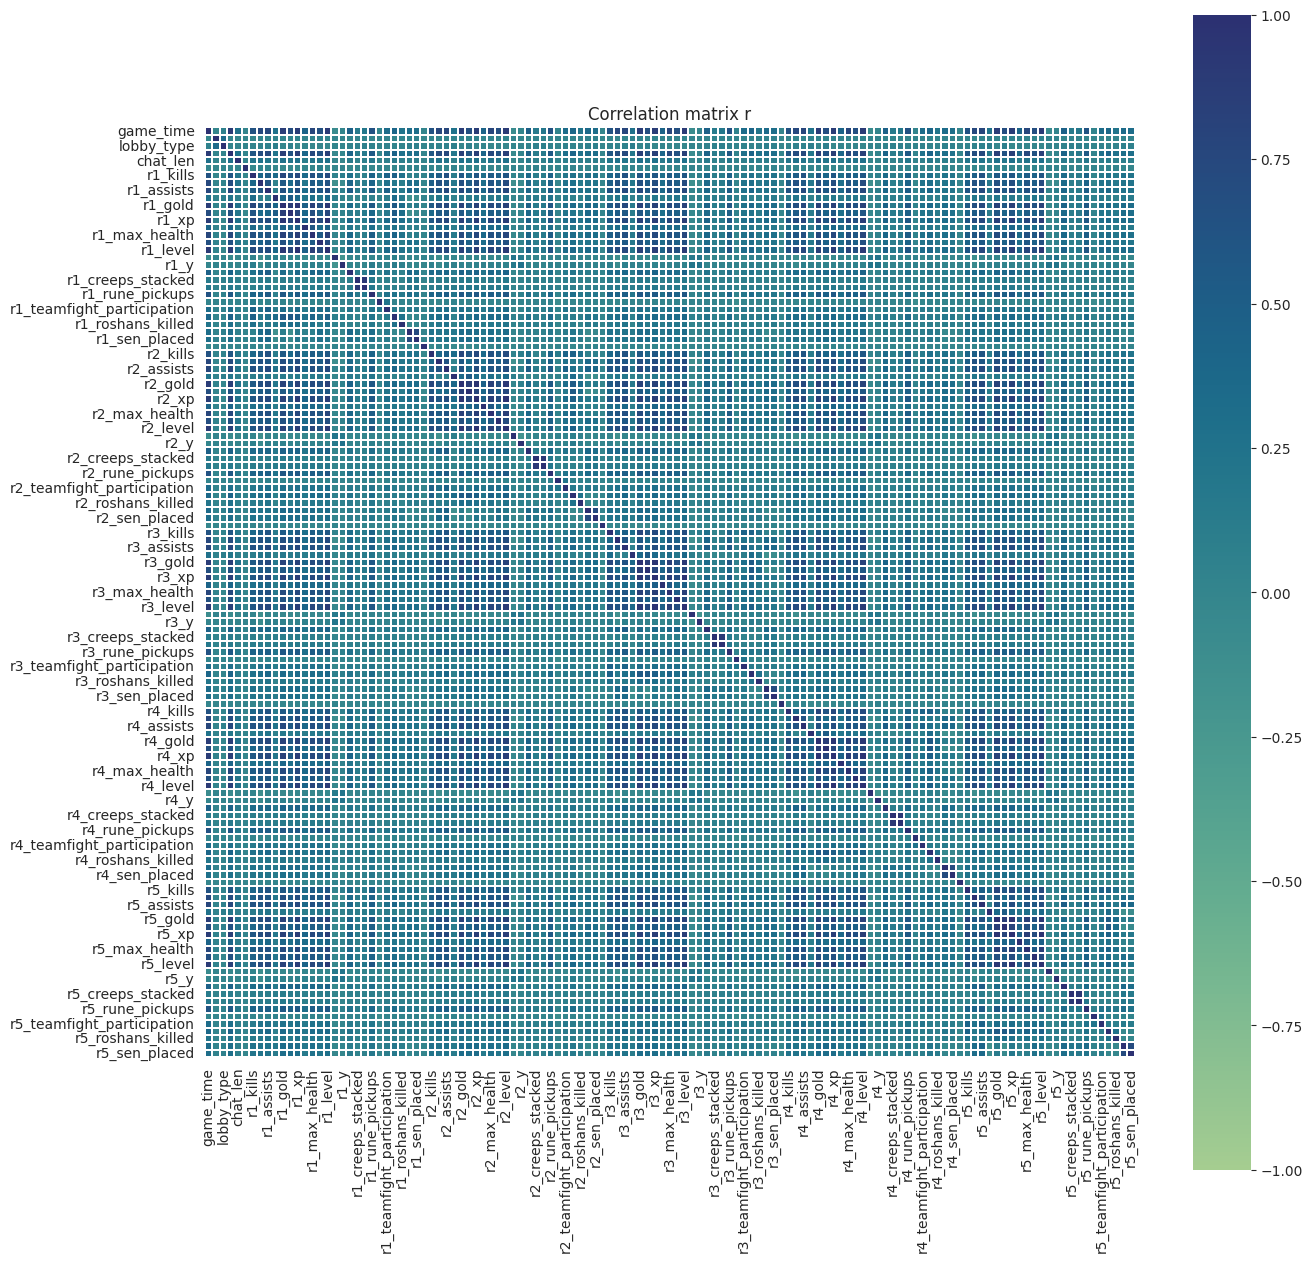

In [81]:
#из визуализации давайте только корреляции глянем (боксплоты и всякое такое нам не сильно поможет, мне кажется)
#т.к. признаков оч много предлагаю сделать так: построить общие признаки+индивидуальные по команде

r_columns = list(df_train_features_extended.columns[0:125])
r_df_train_features_extended = df_train_features_extended[r_columns]
r_correlations = r_df_train_features_extended.corr()

plt.figure(figsize=(15,15))
sns.heatmap(r_correlations, square=True, linewidths=0.25, vmin=-1, vmax=1, cmap="crest")
plt.title("Correlation matrix r")
plt.show();

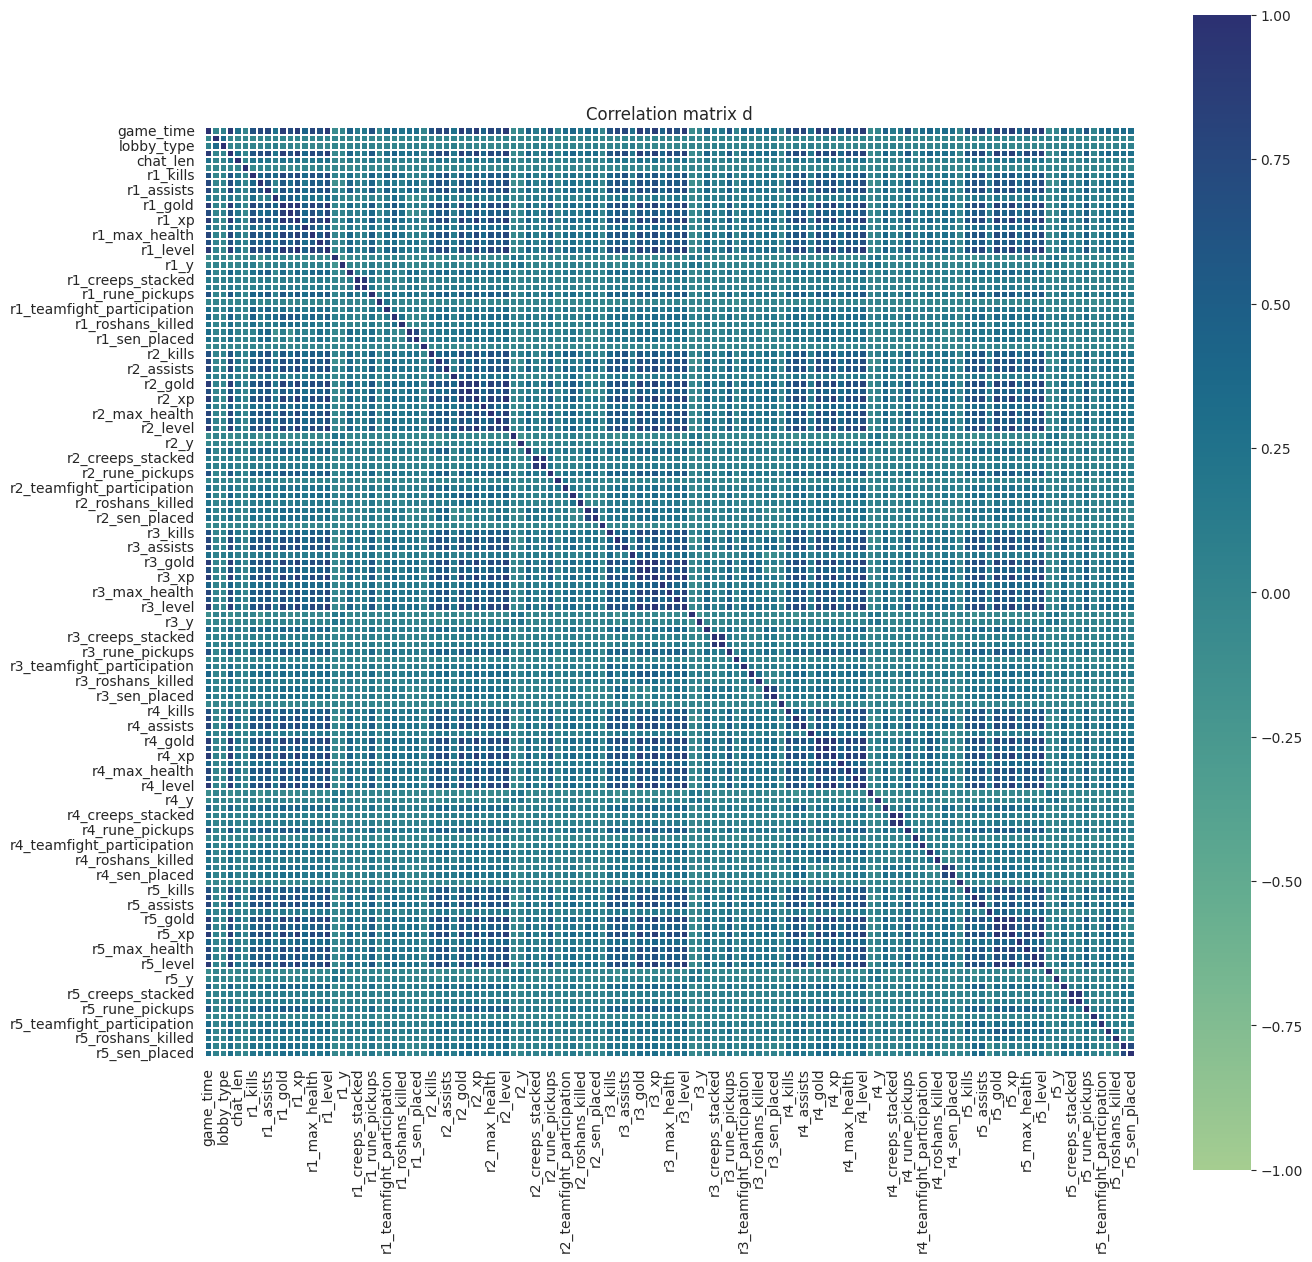

In [82]:
#d
d_columns = list(df_train_features_extended.columns[0:125])
d_df_train_features_extended = df_train_features_extended[d_columns]
d_correlations = d_df_train_features_extended.corr()

plt.figure(figsize=(15,15))
sns.heatmap(d_correlations, square=True, linewidths=0.25, vmin=-1, vmax=1, cmap="crest")
plt.title("Correlation matrix d")
plt.show();

Даже в таком вариате тяжеловато что-то разглядеть, но классно, что у нас как будто фичи типа kills, assists и т.д. бьются по игрокам (в плане для пары игроков аналогичные фичи коррелируют (что называется "командная игра").

Пока ничего дропать не будем (если у нас очень много фичей, то может ансамблю это и хорошо, это может помочь рандомизации предсказаний (а может и не поможет, если индивидуальные модели имеют низкую вероятность).


**Теперь давайте к моделям вернёмся:**

## Кое-что попробуем (назовём "вырубка леса")

Тут бы надо взять уже другую модельку просто, но я на днях наткнулась на [статью на хабре](https://habr.com/ru/articles/767708/) и мне интересно попробовать насколько это сработает. 

Они предлагают улучшить RandomForestClassifier таким образом: когда мы берём ансамбль, то какие-то деревья показывают топ-результат, какие-то дно-результат. И мы уже прошли методы бустинга, когда пытаемся улучшить предсказания плохих моделек, а тут предалают просто убрать плохо-предсказывающие деревья из ансамбля примерно так:

* обучаем ансамбль
* ищем точность на тесте (ну в нашем случае на valid) для каждого отдельного дерева в ансамбле
* оставим только k лучших деревьев в ансамбле

Let's go


In [87]:
#только сначала возьмём наши признаки новые
X_ext = df_train_features_extended.values
y_ext = df_train_targets["radiant_win"].values.astype("int8")
X_train_ext, X_valid_ext, y_train_ext, y_valid_ext = train_test_split(X_ext, y_ext,
                                                                      test_size=0.3,
                                                                      random_state=SEED)

In [34]:
X_ext.shape

(31698, 258)

In [35]:
model = RandomForestClassifier(criterion='entropy', max_depth=15, max_features='log2', n_estimators=500, n_jobs=-1,random_state=SEED)#RandomForestClassifier(n_estimators=300, max_depth=7, n_jobs=-1, random_state=SEED)
model.fit(X_train_ext, y_train_ext)

RandomForestClassifier(criterion='entropy', max_depth=15, max_features='log2',
                       n_estimators=500, n_jobs=-1, random_state=10801)

In [36]:
print("ROC-AUC score на отложенной части для исходной модельки:", roc_auc_score(y_valid_ext, model.predict_proba(X_valid_ext)[:, 1]))
#пока всё как было

ROC-AUC score на отложенной части для исходной модельки: 0.7981605394778717


In [37]:
#мы перебираем все деревья и вычисляем их точность тестирования
model_rauc = []

for idx, tree in enumerate(model.estimators_):

    score = roc_auc_score(y_valid_ext, tree.predict_proba(X_valid_ext)[:, 1])
    model_rauc.append([idx, score])
    
model_rauc = np.array(model_rauc)

In [38]:
#Теперь мы должны переставить модели дерева решений в списке model.estimators_ в порядке убывания точности тестирования
sorted_indices = np.argsort(model_rauc[:, 1])[::-1]
model_ids = model_rauc[sorted_indices][:,0].astype(int)
model_ids[0:5]#лучшее дерево 140ое

array([293, 183, 301, 403,  91])

In [39]:
# а теперь мы просто переставляем их внутри модели как отсортировали
model.estimators_ = np.array(model.estimators_)[model_ids].tolist()

In [40]:
%%time
#Всё. Копируем нашу исходную модельку в small_model. 
#На каждой итерации мы устанавливаем деревья small_model на первые “k” деревьев базовой модели.
#И в итоге оцениваем small_model только с помощью “k” деревьев.
import copy
result = []
total_models = len(model.estimators_) 
for i in range(2, total_models):
    
    small_model = copy.deepcopy(model)
    
    small_model.estimators_ = model.estimators_[:i]
    result.append([i, small_model.score(X_valid_ext, y_valid_ext)])
    
result = np.array(result)

CPU times: user 7min 10s, sys: 13.4 s, total: 7min 23s
Wall time: 3min 23s


In [41]:
#глянем лучший k
max_index = np.argmax(result[:, 1])
max_index

77

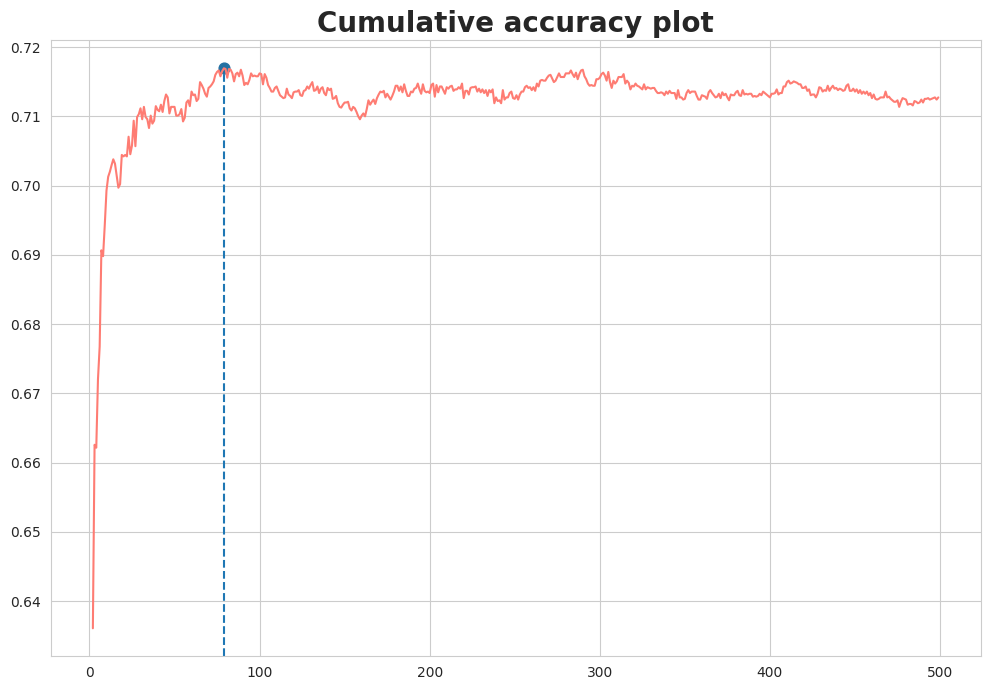

In [42]:
colors = ['#fe7c73', '#2471A3']
fig, ax = plt.subplots()
ax.plot(result[:, 0], result[:, 1], c = colors[0])
ax.axvline(x=result[max_index][0], ymax=0.95, ls = "--")
plt.scatter([result[max_index][0],], [result[max_index][1],], zorder=0, s=60, c = colors[1])

ax.set_title("Cumulative accuracy plot", fontsize = 20, fontweight = "bold")
plt.show()

In [43]:
#теперь берём модельку с лучшим k
small_model = copy.deepcopy(model)
small_model.estimators_ = model.estimators_[:int(result[max_index][0])]

In [44]:
cv_scores_extended_sm = cross_val_score(small_model, df_train_features_extended.values, y,
                                     cv=cv, scoring="roc_auc", n_jobs=-1)

In [45]:
print(f"ROC-AUC на кросс-валидации для новых признаков для маленькой модельки: {cv_scores_extended_sm.mean()}")

ROC-AUC на кросс-валидации для новых признаков для маленькой модельки: 0.7970956588386906


В общем не особо сработало, но прикольно. Вообще это же не только для улучшения качества применимо, но и для быстроты обучения. Но нам не повезло тут (но там и на плоте видно, что это скорее флуктуации, нежели рил норм модель). Надо двигаться дальше.

# Давайте попробуем другую модельку: catboost

*Почему catboost: он хорош для категориальных признаков, с которыми мы ещё не работали здесь + неплох для большого количества данных, что тоже наш случай.*

In [83]:
from catboost import CatBoostClassifier, Pool, cv

In [84]:
df_train_features_extended.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 31698 entries, b9c57c450ce74a2af79c9ce96fac144d to e2ca68ac1a6847f4a37f6c9c8ee8695b
Data columns (total 258 columns):
 #    Column                      Dtype  
---   ------                      -----  
 0    game_time                   int64  
 1    game_mode                   int64  
 2    lobby_type                  int64  
 3    objectives_len              int64  
 4    chat_len                    int64  
 5    r1_hero_id                  int64  
 6    r1_kills                    int64  
 7    r1_deaths                   int64  
 8    r1_assists                  int64  
 9    r1_denies                   int64  
 10   r1_gold                     int64  
 11   r1_lh                       int64  
 12   r1_xp                       int64  
 13   r1_health                   int64  
 14   r1_max_health               int64  
 15   r1_max_mana                 float64
 16   r1_level                    int64  
 17   r1_x                        int64

In [88]:
#сделаем по канону со специальным объектом Pool для представления данных (хотя может это и не канон, но выглядит солиднее и не надо миллион раз прописывать иксы, игреки...)
train_data = Pool(data=X_train_ext, label=y_train_ext)

In [95]:
%%time
#начнём с базы (дефолтные параметры)
cat = CatBoostClassifier(random_seed=SEED, verbose=False)
cat.fit(train_data)

CPU times: user 2min 19s, sys: 4.94 s, total: 2min 24s
Wall time: 39.1 s


In [90]:
%%time
cv = ShuffleSplit(n_splits=5, test_size=0.3, random_state=SEED)
cat = CatBoostClassifier(random_seed=SEED, verbose=False)

cv_scores_extended = cross_val_score(cat, df_train_features_extended.values, y,
                                     cv=cv, scoring="roc_auc", n_jobs=-1)

CPU times: user 1.06 s, sys: 338 ms, total: 1.4 s
Wall time: 3min 41s


In [92]:
print(f"ROC-AUC на кросс-валидации для новых признаков для catboost: {cv_scores_extended.mean()}")

ROC-AUC на кросс-валидации для новых признаков для catboost: 0.8039621663602915


In [96]:
#будем держать перед глазами какие параметры у нас в базовой
cat.get_all_params()#ну будем ориентироваться на что-то наиболее понятное: 'iterations': 1000, 'l2_leaf_reg': 3, 'depth': 6, 'min_data_in_leaf': 1, 'learning_rate': 0.038701001554727554, 'max_leaves': 64

{'nan_mode': 'Min',
 'eval_metric': 'Logloss',
 'iterations': 1000,
 'sampling_frequency': 'PerTree',
 'leaf_estimation_method': 'Newton',
 'random_score_type': 'NormalWithModelSizeDecrease',
 'grow_policy': 'SymmetricTree',
 'penalties_coefficient': 1,
 'boosting_type': 'Plain',
 'model_shrink_mode': 'Constant',
 'feature_border_type': 'GreedyLogSum',
 'bayesian_matrix_reg': 0.10000000149011612,
 'eval_fraction': 0,
 'force_unit_auto_pair_weights': False,
 'l2_leaf_reg': 3,
 'random_strength': 1,
 'rsm': 1,
 'boost_from_average': False,
 'model_size_reg': 0.5,
 'pool_metainfo_options': {'tags': {}},
 'subsample': 0.800000011920929,
 'use_best_model': False,
 'class_names': [0, 1],
 'random_seed': 10801,
 'depth': 6,
 'posterior_sampling': False,
 'border_count': 254,
 'classes_count': 0,
 'auto_class_weights': 'None',
 'sparse_features_conflict_fraction': 0,
 'leaf_estimation_backtracking': 'AnyImprovement',
 'best_model_min_trees': 1,
 'model_shrink_rate': 0,
 'min_data_in_leaf': 1,


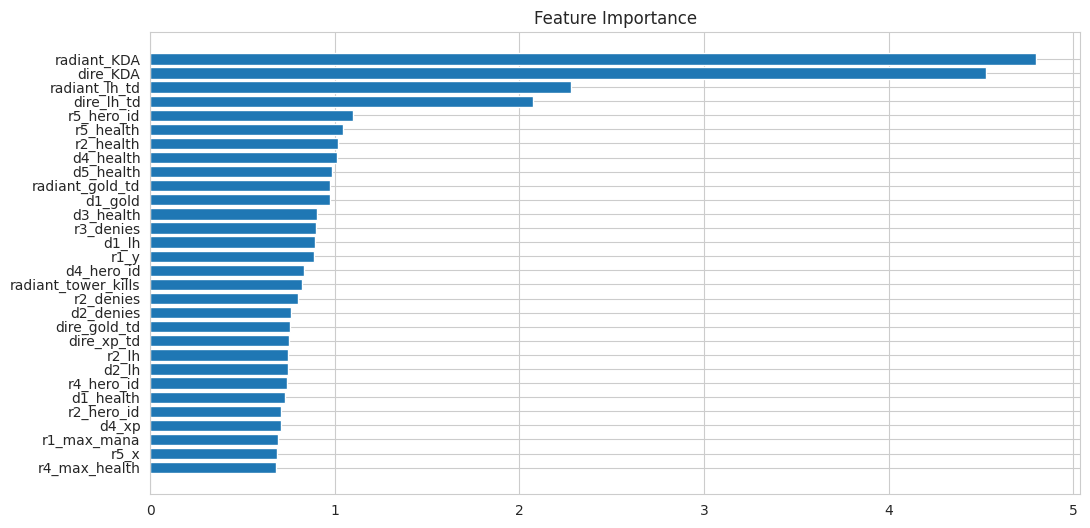

In [97]:
#посмотрим какие признаки важны (топ-30)
feature_importance = cat.feature_importances_
sorted_idx = np.argsort(feature_importance)[-31:-1]
fig = plt.figure(figsize=(12, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(df_train_features_extended.columns)[sorted_idx])
plt.title('Feature Importance');
#у нас опять KDA (что логично выглядит), башни, hero_id(что тоже ожидаемо и логично), даже мой динамический hp_td есть (но это лол)

**Вернёмся к категориальным признакам, которые мы выбрали в разделе EDA**

In [98]:
cat_features=[1, 2, 5, 29, 53, 77, 101, 125, 149, 173, 197, 221]
X_train_ext_df = pd.DataFrame(X_train_ext, columns=df_train_features_extended.columns)
X_train_ext_df[X_train_ext_df.columns[cat_features]] = X_train_ext_df[X_train_ext_df.columns[cat_features]].astype('int')
train_data_cat = Pool(data=X_train_ext_df, label=y_train_ext, cat_features=cat_features)#добавим обязательно сюда

In [99]:
%%time

cat_cat = CatBoostClassifier(random_seed=SEED, verbose=False)
cat_cat.fit(train_data_cat)

CPU times: user 5min 24s, sys: 40.3 s, total: 6min 4s
Wall time: 1min 39s


In [100]:
X_valid_ext_df = pd.DataFrame(X_valid_ext, columns=df_train_features_extended.columns)
X_valid_ext_df[X_valid_ext_df.columns[cat_features]] = X_valid_ext_df[X_valid_ext_df.columns[cat_features]].astype('int')

In [101]:
%%time
cv = ShuffleSplit(n_splits=5, test_size=0.3, random_state=SEED)

cv_scores_extended = cross_val_score(cat_cat, df_train_features_extended.values, y,
                                     cv=cv, scoring="roc_auc", n_jobs=-1)

CPU times: user 1.12 s, sys: 559 ms, total: 1.68 s
Wall time: 3min 40s


In [102]:
print(f"ROC-AUC на кросс-валидации для новых признаков для catboost: {cv_scores_extended.mean()}")

ROC-AUC на кросс-валидации для новых признаков для catboost: 0.8039621663602915


In [103]:
print("ROC-AUC score для базового catboost (не кросс-валидация):", roc_auc_score(y_valid, cat_cat.predict_proba(X_valid_ext_df)[:, 1]))
#ну прям на капельку лучше да

ROC-AUC score для базового catboost (не кросс-валидация): 0.8066681585934093


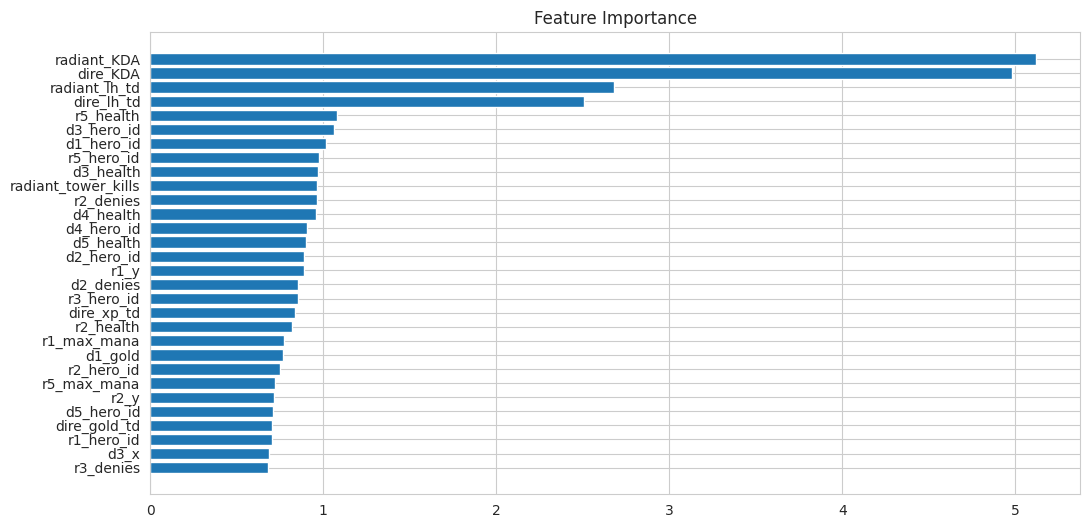

In [104]:
#посмотрим какие признаки важны (топ-30)
feature_importance = cat_cat.feature_importances_
sorted_idx = np.argsort(feature_importance)[-31:-1]
fig = plt.figure(figsize=(12, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(df_train_features_extended.columns)[sorted_idx])
plt.title('Feature Importance');
#не сильно что-то поменялось

In [105]:
#посылка
#теперь моделька
cat_cat.fit(df_train_features_extended.values, y)
X_test = df_test_features_extended.values
y_test_pred = rf_model_ext.predict_proba(X_test)[:, 1]

In [ ]:
#сама посылка
df_submission_extended = pd.DataFrame({"radiant_win_prob": y_test_pred},
                                 index=df_test_features_extended.index)

submission_filename = "submission_{}.csv".format(
    datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S"))
df_submission_extended.to_csv(submission_filename)
print("Файл посылки сохранен, как: {}".format(submission_filename))

**Давайте запускать GridSearch**

In [59]:
%%time
cat = CatBoostClassifier()
space_cat = {
    'iterations': [100, 500, 1000],
    'learning_rate': [0.01, 0.1, 0.3, 1],
    'depth': [2, 3, 7],
    'loss_function': ['Logloss', 'CrossEntropy'],
    'eval_metric': ['AUC'],
    'random_state': [SEED]
}

grid_search = GridSearchCV(
    estimator=cat,
    param_grid=space_cat,
    scoring='roc_auc',
    n_jobs=-1,
    cv=5#,
    #verbose=1
)

grid_search.fit(df_train_features_extended.values, y)

0:	total: 107ms	remaining: 10.6s
1:	total: 185ms	remaining: 9.05s
2:	total: 252ms	remaining: 8.14s
3:	total: 325ms	remaining: 7.79s
4:	total: 390ms	remaining: 7.4s
5:	total: 468ms	remaining: 7.33s
6:	total: 524ms	remaining: 6.96s
7:	total: 594ms	remaining: 6.83s
8:	total: 664ms	remaining: 6.71s
9:	total: 728ms	remaining: 6.55s
10:	total: 843ms	remaining: 6.82s
11:	total: 923ms	remaining: 6.77s
12:	total: 963ms	remaining: 6.45s
13:	total: 999ms	remaining: 6.13s
14:	total: 1.04s	remaining: 5.91s
15:	total: 1.1s	remaining: 5.77s
16:	total: 1.16s	remaining: 5.67s
17:	total: 1.25s	remaining: 5.69s
18:	total: 1.32s	remaining: 5.63s
19:	total: 1.4s	remaining: 5.59s
20:	total: 1.45s	remaining: 5.46s
21:	total: 1.52s	remaining: 5.41s
22:	total: 1.61s	remaining: 5.4s
23:	total: 1.76s	remaining: 5.59s
24:	total: 1.85s	remaining: 5.56s
25:	total: 1.91s	remaining: 5.42s
26:	total: 1.99s	remaining: 5.38s
27:	total: 2.05s	remaining: 5.28s
28:	total: 2.16s	remaining: 5.28s
29:	total: 2.23s	remaining: 

GridSearchCV(cv=5,
             estimator=<catboost.core.CatBoostClassifier object at 0x79f2fa39e410>,
             n_jobs=-1,
             param_grid={'depth': [2, 3, 7], 'eval_metric': ['AUC'],
                         'iterations': [100, 500, 1000],
                         'learning_rate': [0.01, 0.1, 0.3, 1],
                         'loss_function': ['Logloss', 'CrossEntropy'],
                         'random_state': [10801]},
             scoring='roc_auc')

In [60]:
print(grid_search.best_params_)

{'depth': 3, 'eval_metric': 'AUC', 'iterations': 1000, 'learning_rate': 0.1, 'loss_function': 'Logloss', 'random_state': 10801}
822:	total: 3m	remaining: 38.8s
823:	total: 3m	remaining: 38.5s
824:	total: 3m	remaining: 38.3s
825:	total: 3m	remaining: 38.1s
826:	total: 3m 1s	remaining: 37.9s
827:	total: 3m 1s	remaining: 37.6s
828:	total: 3m 1s	remaining: 37.4s
829:	total: 3m 1s	remaining: 37.2s
830:	total: 3m 1s	remaining: 37s
831:	total: 3m 2s	remaining: 36.8s
832:	total: 3m 2s	remaining: 36.6s
833:	total: 3m 2s	remaining: 36.4s
834:	total: 3m 2s	remaining: 36.1s
835:	total: 3m 3s	remaining: 36s
836:	total: 3m 3s	remaining: 35.7s
837:	total: 3m 3s	remaining: 35.5s
838:	total: 3m 3s	remaining: 35.3s
839:	total: 3m 4s	remaining: 35.1s
840:	total: 3m 4s	remaining: 34.8s
841:	total: 3m 4s	remaining: 34.6s
842:	total: 3m 4s	remaining: 34.4s
843:	total: 3m 4s	remaining: 34.2s
844:	total: 3m 4s	remaining: 33.9s
845:	total: 3m 5s	remaining: 33.7s
846:	total: 3m 5s	remaining: 33.5s
847:	total: 3

In [106]:
#лучшая
cat_best = CatBoostClassifier(depth=3, iterations=1000, learning_rate=0.1, loss_function='Logloss', random_state=SEED)

cat_best.fit(df_train_features_extended.values, y)
X_test = df_test_features_extended.values
y_test_pred = cat_best.predict_proba(X_test)[:, 1]

0:	learn: 0.6708536	total: 26.8ms	remaining: 26.8s
1:	learn: 0.6528604	total: 49.2ms	remaining: 24.5s
2:	learn: 0.6379653	total: 75ms	remaining: 24.9s
3:	learn: 0.6261164	total: 99ms	remaining: 24.7s
4:	learn: 0.6163486	total: 122ms	remaining: 24.2s
5:	learn: 0.6074258	total: 145ms	remaining: 24s
6:	learn: 0.6007424	total: 169ms	remaining: 24s
7:	learn: 0.5944951	total: 191ms	remaining: 23.6s
8:	learn: 0.5896906	total: 217ms	remaining: 23.9s
9:	learn: 0.5847861	total: 243ms	remaining: 24.1s
10:	learn: 0.5806027	total: 263ms	remaining: 23.6s
11:	learn: 0.5770652	total: 283ms	remaining: 23.3s
12:	learn: 0.5748921	total: 309ms	remaining: 23.5s
13:	learn: 0.5720958	total: 330ms	remaining: 23.2s
14:	learn: 0.5700109	total: 354ms	remaining: 23.2s
15:	learn: 0.5679127	total: 377ms	remaining: 23.2s
16:	learn: 0.5654397	total: 401ms	remaining: 23.2s
17:	learn: 0.5640922	total: 426ms	remaining: 23.3s
18:	learn: 0.5626750	total: 455ms	remaining: 23.5s
19:	learn: 0.5614987	total: 480ms	remaining: 

In [107]:
%%time
cv = ShuffleSplit(n_splits=5, test_size=0.3, random_state=SEED)
cat = CatBoostClassifier(depth=3, iterations=1000, learning_rate=0.1, loss_function='Logloss', random_state=SEED)

cv_scores_extended = cross_val_score(cat, df_train_features_extended.values, y,
                                     cv=cv, scoring="roc_auc", n_jobs=-1)

0:	learn: 0.6738396	total: 102ms	remaining: 1m 41s
1:	learn: 0.6554335	total: 216ms	remaining: 1m 47s
2:	learn: 0.6409592	total: 311ms	remaining: 1m 43s
3:	learn: 0.6273087	total: 458ms	remaining: 1m 54s
4:	learn: 0.6171515	total: 544ms	remaining: 1m 48s
5:	learn: 0.6082199	total: 657ms	remaining: 1m 48s
6:	learn: 0.6015700	total: 742ms	remaining: 1m 45s
7:	learn: 0.5951545	total: 851ms	remaining: 1m 45s
8:	learn: 0.5894398	total: 957ms	remaining: 1m 45s
9:	learn: 0.5852556	total: 1.06s	remaining: 1m 45s
10:	learn: 0.5813281	total: 1.21s	remaining: 1m 49s
11:	learn: 0.5780275	total: 1.35s	remaining: 1m 51s
12:	learn: 0.5745720	total: 1.4s	remaining: 1m 46s
13:	learn: 0.5716129	total: 1.48s	remaining: 1m 44s
14:	learn: 0.5694089	total: 1.61s	remaining: 1m 45s
15:	learn: 0.5678696	total: 1.79s	remaining: 1m 50s
16:	learn: 0.5664140	total: 1.86s	remaining: 1m 47s
17:	learn: 0.5645363	total: 1.98s	remaining: 1m 47s
18:	learn: 0.5629830	total: 2.08s	remaining: 1m 47s
19:	learn: 0.5616993	to

In [108]:
print(f"ROC-AUC на кросс-валидации для новых признаков для лучшего catboost: {cv_scores_extended.mean()}")

ROC-AUC на кросс-валидации для новых признаков для лучшего catboost: 0.8032875057084137


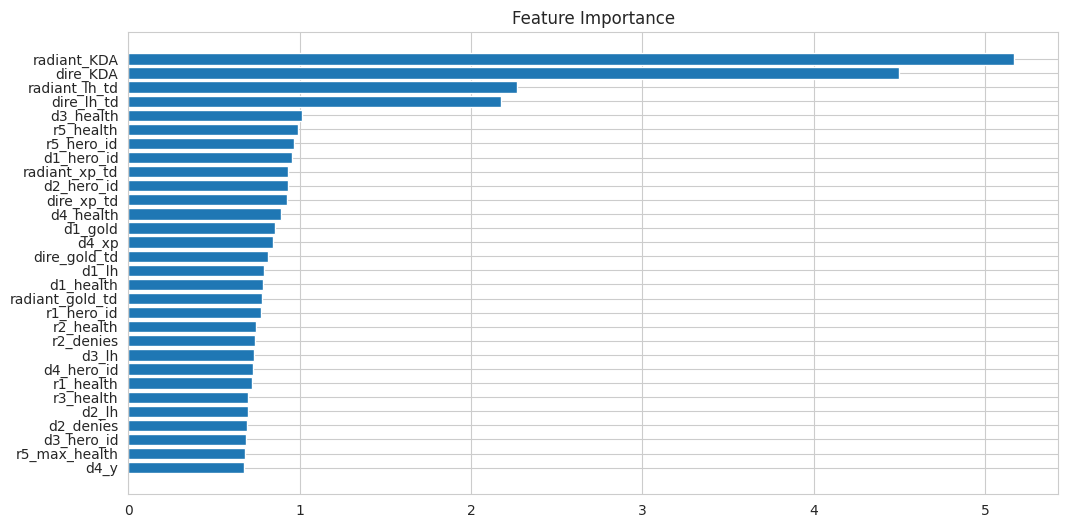

In [109]:
#посмотрим какие признаки важны (топ-30)
feature_importance = cat_cat.feature_importances_
sorted_idx = np.argsort(feature_importance)[-31:-1]
fig = plt.figure(figsize=(12, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(df_train_features_extended.columns)[sorted_idx])
plt.title('Feature Importance');
#не сильно что-то поменялось

In [64]:
#теперь моделька
cat.fit(df_train_features_extended.values, y)
X_test = df_test_features_extended.values
y_test_pred = rf_model_ext.predict_proba(X_test)[:, 1]

0:	learn: 0.6708536	total: 28.1ms	remaining: 28.1s
1:	learn: 0.6528604	total: 49.9ms	remaining: 24.9s
2:	learn: 0.6379653	total: 75ms	remaining: 24.9s
3:	learn: 0.6261164	total: 99.5ms	remaining: 24.8s
4:	learn: 0.6163486	total: 123ms	remaining: 24.4s
5:	learn: 0.6074258	total: 146ms	remaining: 24.2s
6:	learn: 0.6007424	total: 171ms	remaining: 24.2s
7:	learn: 0.5944951	total: 193ms	remaining: 23.9s
8:	learn: 0.5896906	total: 218ms	remaining: 24s
9:	learn: 0.5847861	total: 244ms	remaining: 24.1s
10:	learn: 0.5806027	total: 264ms	remaining: 23.7s
11:	learn: 0.5770652	total: 284ms	remaining: 23.4s
12:	learn: 0.5748921	total: 311ms	remaining: 23.6s
13:	learn: 0.5720958	total: 331ms	remaining: 23.3s
14:	learn: 0.5700109	total: 355ms	remaining: 23.3s
15:	learn: 0.5679127	total: 379ms	remaining: 23.3s
16:	learn: 0.5654397	total: 403ms	remaining: 23.3s
17:	learn: 0.5640922	total: 428ms	remaining: 23.3s
18:	learn: 0.5626750	total: 456ms	remaining: 23.5s
19:	learn: 0.5614987	total: 481ms	remaini

In [65]:
#сама посылка
df_submission_extended = pd.DataFrame({"radiant_win_prob": y_test_pred},
                                 index=df_test_features_extended.index)

submission_filename = "submission_{}.csv".format(
    datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S"))
df_submission_extended.to_csv(submission_filename)
print("Файл посылки сохранен, как: {}".format(submission_filename))

Файл посылки сохранен, как: submission_2024-04-06_10-26-54.csv


# Итог

| №  | описание                             | модель                                                                                                                          | кол-во фичей | ~метрика на cv | на каггле | коммент                                  |   |
|----|--------------------------------------|---------------------------------------------------------------------------------------------------------------------------------|--------------|----------------|-----------|------------------------------------------|---|
| 1  | авторские фичи (наша 1ая модель)     | RandomForestClassifier(n_estimators=300, max_depth=7, n_jobs=-1,   random_state=SEED)                                           | 245          | 0.772          | 0.78639   | база                                     |   |
| 2  | добавление вышек (2ая версия модели) | RandomForestClassifier(n_estimators=300, max_depth=7, n_jobs=-1,   random_state=SEED)                                           | 248          | 0.779          | 0.79324   | стало   лучше и признак важен            |   |
| 3  | +KDA (3я версия модели)'             | RandomForestClassifier(n_estimators=300, max_depth=7, n_jobs=-1,   random_state=SEED)                                           | 250          | 0.787          | na        | стало   лучше и признак важен            |   |
| 4  | +ability_uses (3я версия модели)'    | RandomForestClassifier(n_estimators=300, max_depth=7, n_jobs=-1,   random_state=SEED)                                           | 252          | 0.787          | na        | не   особо изменилось                    |   |
| 5  | +xp_td (3я версия модели)'           | RandomForestClassifier(n_estimators=300, max_depth=7, n_jobs=-1,   random_state=SEED)                                           | 254          | 0.787          | 0.7974    | не   особо изменилось                    |   |
| 6  | +gold_td (3я версия модели)'         | RandomForestClassifier(n_estimators=300, max_depth=7, n_jobs=-1,   random_state=SEED)                                           | 256          | 0.787          | na        | не   особо изменилось, даже упало скорее |   |
| 7  | +lh_td (3я версия модели)'           | RandomForestClassifier(n_estimators=300, max_depth=7, n_jobs=-1,   random_state=SEED)                                           | 258          | 0.788          | na        | не   особо изменилось                    |   |
| 8  | 7-gold_td                            | RandomForestClassifier(n_estimators=300, max_depth=7, n_jobs=-1,   random_state=SEED)                                           | 256          | 0.787          | na        | хуже чем с gold_td                       |   |
| 9  | rf_best (searchgrid)                 | RandomForestClassifier(criterion='entropy', max_depth=15,   max_features='log2', n_estimators=500, n_jobs=-1,random_state=SEED) | 258          | 0.797          | na        | лучше                                    |   |
| 10 | "вырубка леса"                       | small_model от с k=37 от RandomForestClassifier(n_estimators=300,   max_depth=7, n_jobs=-1, random_state=SEED)                  | 258          | 0.788          | na        | не помогло                               |   |
| 11 | "вырубка леса" на бесте (9)          | small_model от с k=37 от RandomForestClassifier(n_estimators=300,   max_depth=7, n_jobs=-1, random_state=SEED)                  | 258          | 0.797          | na        | не помогло                               |   |
| 12 | catboost дефолтный                   | CatBoostClassifier(random_seed=SEED, verbose=False)                                                                             | 258          | 0.788          | na        | бустанул,   но не лучше лучшего rf       |   |
| 13 | catboost_best (после гридсёрча)      | CatBoostClassifier(random_seed=SEED, verbose=False)                                                                             | 254          | 0.803          | na        | бустанул   лучше                         |   |